# FoV prediction: one video, 50 behaviours, order-5 predictor

This notebook follows the teacher's setup exactly.

| step | what it means here |
|---|---|
| **1 video** | one 60 s video at 30 fps (1800 frames), chosen in `Cfg.video` |
| **1 sample per 5 s** | $F_k$ = the 10×20 tile map of the **single frame** at $t = 5k$ s, for $k = 1..12$ |
| **50 behaviours** | the 50 viewers of that video, each giving $F_1 \dots F_{12}$ |
| **order N = 5** | $\hat F_{n+1} = f_\theta(F_n, F_{n-1}, F_{n-2}, F_{n-3}, F_{n-4})$ |
| **pairs** | $12 - 5 = 7$ per behaviour, so $50 \times 7 = 350$ |
| **loss** | $L(\theta) = \lVert \hat F_\theta(F_n,\dots,F_{n-N+1}) - F_{n+1} \rVert_2^2$, averaged over the training pairs |
| **update** | $\theta^{(e+1)} \leftarrow \theta^{(e)} - \eta_e \, \partial L / \partial \theta$ (plain gradient descent, one full-batch step per epoch) |
| **learning rate** | $\eta_e = a / (b + e)$ |
| **deliverables** | Epoch → RMSE and Epoch → learning-rate plots over 600 epochs |

**Split.** The 50 behaviours are split by viewer: **35 train (245 pairs)** and
**15 test (105 pairs)**. The same seed-0 shuffle as the earlier notebooks is used,
so the test viewers are the same people. The test curve shows whether the
predictor learned the *distribution* of viewing behaviour, not just the 35 people it saw.

> ⚠️ **`a` and `b` are not confirmed.** The handwriting looks like `a = 0.1`,
> `b = 0.5`. Both are set in the config cell. Change them once the teacher confirms.

In [11]:
import os, re, glob, time, json, random, platform, shutil
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
%matplotlib inline

print("PyTorch:", torch.__version__)

def find_data_root():
    for base in ("/kaggle/input", ".", "../dataset", ".."):
        if not os.path.isdir(base):
            continue
        for root, dirs, _ in os.walk(base):
            if os.path.isdir(os.path.join(root, "sensory", "tile")):
                return root
    raise FileNotFoundError("could not find a folder containing sensory/tile")

DATA_ROOT = find_data_root()
WORK_DIR  = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
OUT_DIR   = os.path.join(WORK_DIR, "order5_outputs")
os.makedirs(OUT_DIR, exist_ok=True)
print("DATA_ROOT =", os.path.abspath(DATA_ROOT))
print("outputs   ->", os.path.abspath(OUT_DIR))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 200)

PyTorch: 2.14.1+cpu
DATA_ROOT = /home/shashank-t1wari/Downloads/capstone-code/dataset/360dataset
outputs   -> /home/shashank-t1wari/Downloads/capstone-code/predictor/order5_outputs


## 0. Hardware check

The device is picked automatically. There is no flag to set.

| found | used |
|---|---|
| NVIDIA GPU (or an AMD GPU with a ROCm build of PyTorch) | `cuda` |
| Intel Arc GPU with an XPU build of PyTorch | `xpu` |
| Apple Silicon GPU | `mps` |
| none of the above | `cpu` |

Before a GPU is used, it runs a small test convolution. If PyTorch reports a GPU
but cannot run on it, the notebook prints why and tries the next option, ending at the CPU.

TF32 is turned off, so NVIDIA GPUs compute in full float32 like the CPU does.
Results on different team machines then agree up to float rounding.

In [13]:
def pick_device():
    # Use a GPU when one is present and works, otherwise the CPU.
    found = []
    if torch.cuda.is_available():                                          # NVIDIA, or AMD via ROCm
        found.append(("cuda", torch.cuda.get_device_name(0)))
    if hasattr(torch, "xpu") and torch.xpu.is_available():                 # Intel Arc
        found.append(("xpu", torch.xpu.get_device_name(0)))
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():   # Apple Silicon
        found.append(("mps", "Apple Silicon GPU"))

    for kind, name in found:
        dev = torch.device(kind)
        try:   # a PyTorch build can list a GPU it has no kernels for, so run a real conv on it
            x = torch.ones(1, 1, 4, 4, device=dev)
            nn.functional.conv2d(x, torch.ones(1, 1, 3, 3, device=dev)).sum().item()
            return dev, name
        except Exception as err:
            print(f"[warn] {kind} device '{name}' was found but cannot run: {err}")

    if shutil.which("nvidia-smi") and torch.version.cuda is None:
        print("[hint] an NVIDIA driver is installed but this PyTorch build is CPU-only.\n"
              "       Install the CUDA build with the command from https://pytorch.org/get-started/locally/")
    return torch.device("cpu"), platform.processor() or platform.machine()


DEVICE, DEVICE_NAME = pick_device()

# full float32 on NVIDIA too (no TF32), and deterministic cuDNN kernels
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print(f"device: {DEVICE.type}  ({DEVICE_NAME})")

device: cpu  (x86_64)


## 1. Settings

Every number from the teacher's sheet is in this one cell.

In [14]:
@dataclass
class Cfg:
    video: str = "coaster"      # the ONE video
    fps: int = 30
    video_seconds: int = 60
    sample_every_s: int = 5     # 1 FoV sample per 5 s  -> 12 samples
    order: int = 5              # N: previous samples used per prediction

    grid_h: int = 10
    grid_w: int = 20

    n_train_users: int = 35     # the other 15 behaviours are the test set

    # learning rate  eta_e = a / (b + e)   <-- NOT CONFIRMED, check with teacher
    lr_a: float = 0.1
    lr_b: float = 0.5
    epochs: int = 600

    width: int = 16             # conv filters in the predictor
    seed: int = 0

    @property
    def n_samples(self):  return self.video_seconds // self.sample_every_s
    @property
    def pairs_per_user(self):  return self.n_samples - self.order


cfg = Cfg()

def lr_at(e, c=cfg):
    return c.lr_a / (c.lr_b + e)

print(f"video            {cfg.video}")
print(f"samples/behaviour {cfg.n_samples}  (t = {cfg.sample_every_s}, "
      f"{2*cfg.sample_every_s}, ..., {cfg.video_seconds} s)")
print(f"order N          {cfg.order}")
print(f"pairs/behaviour  {cfg.n_samples} - {cfg.order} = {cfg.pairs_per_user}")
print(f"learning rate    eta_e = {cfg.lr_a} / ({cfg.lr_b} + e)  "
      f"-> e=1: {lr_at(1):.4f}, e={cfg.epochs}: {lr_at(cfg.epochs):.2e}")

video            coaster
samples/behaviour 12  (t = 5, 10, ..., 60 s)
order N          5
pairs/behaviour  12 - 5 = 7
learning rate    eta_e = 0.1 / (0.5 + e)  -> e=1: 0.0667, e=600: 1.67e-04


## 2. From a 1-minute video to 12 FoV samples per behaviour

Each `sensory/tile/<video>_<user>_tile.csv` lists, for every frame, the tile
indices inside the viewport. Tile $t$ is at row $t \,//\, 20$ and column $t \bmod 20$.

$F_k$ is the frame at $t = 5k$ s, which is frame $150k$ (1-based). So
$F_1$ is frame 150, $F_2$ is frame 300, and so on up to $F_{12}$ = frame 1800.

In [15]:
def parse_tile_csv(path, gh=cfg.grid_h, gw=cfg.grid_w):
    # Ragged 'frame, tile, tile, ...' CSV -> (n_frames, gh, gw) 0/1 array.
    occ = []
    with open(path) as f:
        f.readline()
        for line in f:
            parts = [p.strip() for p in line.strip().split(",")]
            if not parts or parts[0] == "":
                continue
            g = np.zeros((gh, gw), np.float32)
            for t in (int(p) for p in parts[1:] if p != ""):
                r, c = divmod(t, gw)
                if 0 <= r < gh and 0 <= c < gw:
                    g[r, c] = 1.0
            occ.append(g)
    return np.stack(occ)


def fov_samples(occ, c=cfg):
    # The 12 FoV samples F_1..F_12: the frame at t = 5, 10, ..., 60 s.
    step = c.sample_every_s * c.fps
    idx = [min(k * step, len(occ)) - 1 for k in range(1, c.n_samples + 1)]
    return occ[idx], idx


tile_dir = os.path.join(DATA_ROOT, "sensory", "tile")
rx = re.compile(rf"^{re.escape(cfg.video)}_(user\d+)_tile\.csv$")
USERS = sorted(m.group(1) for p in glob.glob(os.path.join(tile_dir, "*_tile.csv"))
               if (m := rx.match(os.path.basename(p))))
assert USERS, f"no tile CSVs found for video '{cfg.video}'"

F = {}                 # user -> (12, 10, 20)
n_frames = {}
for u in USERS:
    occ = parse_tile_csv(os.path.join(tile_dir, f"{cfg.video}_{u}_tile.csv"))
    F[u], idx = fov_samples(occ)
    n_frames[u] = len(occ)

short = {u: n for u, n in n_frames.items() if n < cfg.video_seconds * cfg.fps}
print(f"{len(USERS)} user behaviours for '{cfg.video}'")
print(f"frames per behaviour: min {min(n_frames.values())}, max {max(n_frames.values())}")
if short:
    print(f"[warn] {len(short)} behaviour(s) shorter than {cfg.video_seconds} s; "
          f"their last sample uses the final frame: {short}")
print("sampled frame numbers (1-based):", [i + 1 for i in idx])
print("tiles in view per sample (mean over behaviours):",
      np.round(np.mean([F[u].sum((1, 2)) for u in USERS], 0), 1))

50 user behaviours for 'coaster'
frames per behaviour: min 1800, max 1800
sampled frame numbers (1-based): [150, 300, 450, 600, 750, 900, 1050, 1200, 1350, 1500, 1650, 1800]
tiles in view per sample (mean over behaviours): [32.8 32.  33.4 32.  33.5 35.5 32.5 32.5 33.4 32.6 33.  32.1]


### What the 12 samples look like for one behaviour

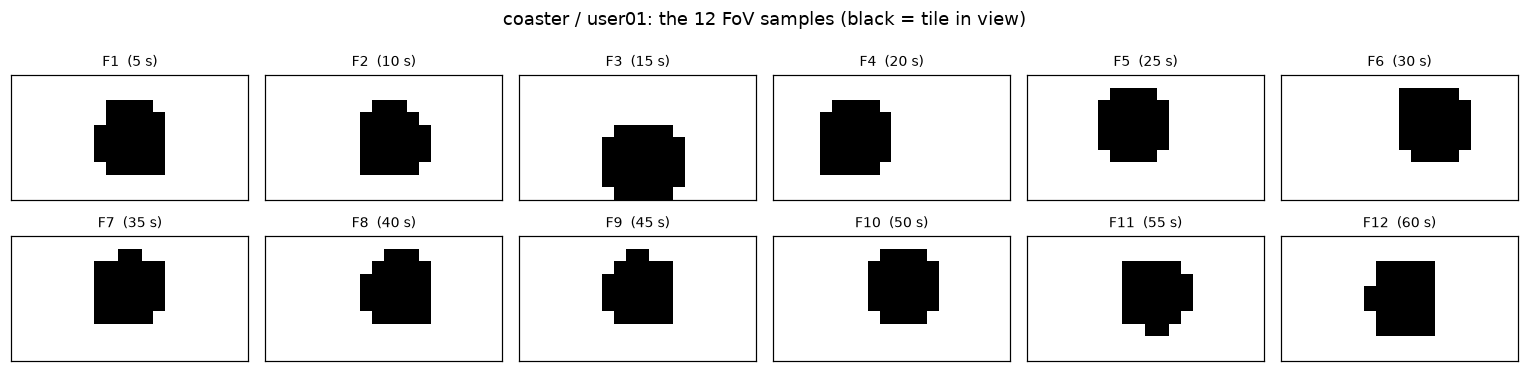

In [16]:
u0 = USERS[0]
fig, axes = plt.subplots(2, 6, figsize=(14, 3.4))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(F[u0][k], cmap="Greys", vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"F{k+1}  ({(k+1)*cfg.sample_every_s} s)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"{cfg.video} / {u0}: the 12 FoV samples (black = tile in view)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "samples_one_user.png"), dpi=130)
plt.show()

## 3. Sliding window: 7 input → target pairs per behaviour

```
F1 F2 F3 F4 F5    ->  F6
F2 F3 F4 F5 F6    ->  F7
...
F7 F8 F9 F10 F11  ->  F12
```
The 5 input maps are stacked as 5 channels, **oldest first**, so the input is 10×20×5.

In [17]:
def make_pairs(users, c=cfg):
    X, Y, meta = [], [], []
    for u in users:
        s = F[u]
        for n in range(c.order, c.n_samples):          # n = index of the target (0-based)
            X.append(np.moveaxis(s[n - c.order:n], 0, -1))   # (10, 20, 5), oldest first
            Y.append(s[n])
            meta.append((u, n + 1))                         # target is F_{n+1} (1-based)
    return (np.stack(X).astype(np.float32), np.stack(Y).astype(np.float32),
            pd.DataFrame(meta, columns=["user", "target_k"]))


rng = np.random.default_rng(cfg.seed)
shuf = list(USERS); rng.shuffle(shuf)
TRAIN_USERS = sorted(shuf[:cfg.n_train_users])
TEST_USERS  = sorted(shuf[cfg.n_train_users:])
assert not set(TRAIN_USERS) & set(TEST_USERS)

X_all, Y_all, _ = make_pairs(USERS)
X_tr, Y_tr, M_tr = make_pairs(TRAIN_USERS)
X_te, Y_te, M_te = make_pairs(TEST_USERS)

print(f"all behaviours : {len(USERS)} x {cfg.pairs_per_user} = {len(X_all)} pairs")
print(f"train          : {len(TRAIN_USERS)} x {cfg.pairs_per_user} = {len(X_tr)} pairs")
print(f"test           : {len(TEST_USERS)} x {cfg.pairs_per_user} = {len(X_te)} pairs")
print(f"input shape {X_tr.shape[1:]}, target shape {Y_tr.shape[1:]}")
print("test viewers:", TEST_USERS)

all behaviours : 50 x 7 = 350 pairs
train          : 35 x 7 = 245 pairs
test           : 15 x 7 = 105 pairs
input shape (10, 20, 5), target shape (10, 20)
test viewers: ['user06', 'user08', 'user10', 'user13', 'user14', 'user15', 'user16', 'user30', 'user32', 'user34', 'user40', 'user41', 'user42', 'user43', 'user50']


## 4. Reference points (no learning)

These give the RMSE curve something to be compared against.

| baseline | prediction of $F_{n+1}$ |
|---|---|
| **constant** | the training base rate on every tile |
| **persistence** | $F_n$, i.e. "the viewer keeps looking where they are" |
| **crowd mean** | the average of the 35 training viewers' $F_{n+1}$ at the same time step |

RMSE is $\sqrt{\text{mean over pairs and tiles of } (\hat F - F)^2}$ throughout.

In [19]:
def rmse(p, y):
    return float(np.sqrt(np.mean((np.asarray(p) - np.asarray(y)) ** 2)))

BASE_RATE = float(Y_tr.mean())
crowd_by_k = {k: np.mean([F[u][k - 1] for u in TRAIN_USERS], 0)
              for k in range(cfg.order + 1, cfg.n_samples + 1)}

def baselines(X, Y, M):
    return {
        "constant":    rmse(np.full_like(Y, BASE_RATE), Y),
        "persistence": rmse(X[..., -1], Y),
        "crowd mean":  rmse(np.stack([crowd_by_k[k] for k in M.target_k]), Y),
    }

BASE_TR, BASE_TE = baselines(X_tr, Y_tr, M_tr), baselines(X_te, Y_te, M_te)
print(f"base rate (train) = {BASE_RATE:.4f}\n")
print(pd.DataFrame({"train RMSE": BASE_TR, "test RMSE": BASE_TE}).round(4))

base rate (train) = 0.1652

             train RMSE  test RMSE
constant         0.3714     0.3720
persistence      0.3132     0.3299
crowd mean       0.2529     0.2683


## 5. The predictor $f_\theta$

A small CNN. Columns wrap around because longitude is 360°. Rows are zero-padded
because latitude does not wrap.

```
input 10×20×5  (F_{n-4} … F_n)
  → circular pad 1 → conv 3×3, 16 filters, ReLU
  → circular pad 2 → conv 3×3, 16 filters, dilation 2, ReLU
  → conv 1×1 → 1 logit per tile (bias starts at logit(base rate))
  → sigmoid → F̂_{n+1}, a 10×20 map in [0, 1]
```

**Starting weights $\theta^{(0)}$.** Kernels are drawn from Glorot-uniform and biases start at
zero, except the output bias, which starts at logit(base rate). With $\eta_1 \approx 0.067$ the
first steps are large, so where training ends depends on the starting draw. Some draws stall
at a higher RMSE. For seed 0 the three kernels are read from `order5_init_seed0.npz`, so every
machine (CPU or GPU) starts from the same $\theta^{(0)}$ and gets the same curves. With another
`seed`, or if the file is missing, a fresh draw is used instead. The cell prints which one it used.

In [20]:
class CircularPad(nn.Module):
    # Wrap columns (longitude), zero-pad rows (latitude). x is (N, C, H, W).
    def __init__(self, p):
        super().__init__(); self.p = p
    def forward(self, x):
        p = self.p
        x = torch.cat([x[..., -p:], x, x[..., :p]], dim=3)
        return nn.functional.pad(x, (0, 0, p, p))


class Order5Predictor(nn.Module):
    def __init__(self, c=cfg):
        super().__init__()
        self.pad1  = CircularPad(1)
        self.conv1 = nn.Conv2d(c.order, c.width, 3)
        self.pad2  = CircularPad(2)
        self.conv2 = nn.Conv2d(c.width, c.width, 3, dilation=2)
        self.head  = nn.Conv2d(c.width, 1, 1)
        # Keras defaults: Glorot-uniform kernels and zero biases.
        # The output bias starts at logit(base rate).
        for conv in (self.conv1, self.conv2, self.head):
            nn.init.xavier_uniform_(conv.weight)
            nn.init.zeros_(conv.bias)
        nn.init.constant_(self.head.bias, float(np.log(BASE_RATE / (1 - BASE_RATE))))

    def forward(self, x):
        # x is (N, 10, 20, 5) like the numpy arrays; torch convs want (N, 5, 10, 20)
        h = x.permute(0, 3, 1, 2)
        h = torch.relu(self.conv1(self.pad1(h)))
        h = torch.relu(self.conv2(self.pad2(h)))
        return torch.sigmoid(self.head(h)).squeeze(1)          # (N, 10, 20)


INIT_FILE = "order5_init_seed0.npz"     # the seed-0 starting kernels, see the cell above

def build_predictor(c=cfg):
    random.seed(c.seed); np.random.seed(c.seed); torch.manual_seed(c.seed)
    model = Order5Predictor(c)
    init = f"fresh Glorot-uniform draw (seed {c.seed})"
    if c.seed == 0 and os.path.exists(INIT_FILE):
        saved = {k: torch.from_numpy(v) for k, v in np.load(INIT_FILE).items()}
        params = dict(model.named_parameters())
        if all(k in params and params[k].shape == v.shape for k, v in saved.items()):
            with torch.no_grad():
                for k, v in saved.items():
                    params[k].copy_(v)
            init = f"seed-0 kernels from {INIT_FILE}"
    print("starting weights:", init)
    return model.to(DEVICE)


def summary(model, c=cfg):
    # Layer table in the style of keras' model.summary(). Shapes are (N, C, H, W).
    rows, hooks = [], []
    for name, m in model.named_children():
        hooks.append(m.register_forward_hook(
            lambda m, i, o, name=name: rows.append(
                (f"{name} ({type(m).__name__})", (None, *o.shape[1:]),
                 sum(p.numel() for p in m.parameters())))))
    with torch.no_grad():
        model(torch.zeros(1, c.grid_h, c.grid_w, c.order, device=DEVICE))
    for h in hooks:
        h.remove()
    print(f'Model: "order5_predictor"   on {DEVICE.type}')
    print(f"{'Layer (type)':<28}{'Output Shape':<24}{'Param #':>8}")
    for name, shape, n in rows:
        print(f"{name:<28}{str(shape):<24}{n:>8,}")
    print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")


model = build_predictor()
summary(model)

starting weights: seed-0 kernels from order5_init_seed0.npz
Model: "order5_predictor"   on cpu
Layer (type)                Output Shape             Param #
pad1 (CircularPad)          (None, 5, 12, 22)              0
conv1 (Conv2d)              (None, 16, 10, 20)           736
pad2 (CircularPad)          (None, 16, 14, 24)             0
conv2 (Conv2d)              (None, 16, 10, 20)         2,320
head (Conv2d)               (None, 1, 10, 20)             17
Total params: 3,073


## 6. Training: plain gradient descent with $\eta_e = a/(b+e)$

For each epoch $e = 1 \dots 600$:

1. **Predict** $\hat F_{n+1}$ for all 245 training pairs with the current weights $\theta^{(e)}$.
2. **Loss** $L(\theta) = \frac{1}{P}\sum_{\text{pairs}} \lVert \hat F_{n+1} - F_{n+1} \rVert_2^2$
   (squared L2 norm over the 200 tiles, averaged over the $P$ pairs).
3. **Gradient** $\partial L / \partial \theta$.
4. **Update** $\theta^{(e+1)} = \theta^{(e)} - \eta_e \, \partial L / \partial \theta$.

The optimizer is the update line itself. There is no Adam and no momentum. The RMSE
logged for epoch $e$ belongs to the weights $\theta^{(e)}$ that made the prediction in
step 1, and test RMSE uses the same weights. The test set is never used for the update.

In [21]:
X_tr_t, Y_tr_t = torch.from_numpy(X_tr).to(DEVICE), torch.from_numpy(Y_tr).to(DEVICE)
X_te_t, Y_te_t = torch.from_numpy(X_te).to(DEVICE), torch.from_numpy(Y_te).to(DEVICE)

def loss_fn(pred, y):
    # ||F_hat - F||_2^2 per pair (sum over the 200 tiles), mean over pairs
    return torch.mean(torch.sum(torch.square(pred - y), dim=(1, 2)))

def gd_step(lr):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, Y_tr_t)
    params = list(model.parameters())
    grads = torch.autograd.grad(loss, params)
    with torch.no_grad():
        for v, g in zip(params, grads):
            v.sub_(lr * g)                         # theta <- theta - eta_e * dL/dtheta
        rmse_tr = torch.sqrt(torch.mean(torch.square(pred - Y_tr_t)))
        gnorm = torch.sqrt(sum(torch.sum(torch.square(g)) for g in grads))
    return loss.detach(), rmse_tr, gnorm

@torch.no_grad()
def test_rmse():
    model.eval()
    pred = model(X_te_t)
    return torch.sqrt(torch.mean(torch.square(pred - Y_te_t)))

@torch.no_grad()
def predict(X_t):
    model.eval()
    return model(X_t).cpu().numpy()


log = []
t0 = time.time()
for e in range(1, cfg.epochs + 1):
    lr = lr_at(e)
    te = float(test_rmse())                         # theta^(e), before the update
    loss, tr, gnorm = gd_step(lr)
    log.append({"epoch": e, "lr": lr, "loss": float(loss),
                "train_rmse": float(tr), "test_rmse": te, "grad_norm": float(gnorm)})
    if e == 1 or e % 50 == 0:
        print(f"epoch {e:4d}  lr {lr:.5f}  loss {float(loss):7.3f}  "
              f"train RMSE {float(tr):.4f}  test RMSE {te:.4f}")

LOG = pd.DataFrame(log)
FINAL_TR = rmse(predict(X_tr_t), Y_tr)
FINAL_TE = rmse(predict(X_te_t), Y_te)
print(f"\ndone in {time.time()-t0:.1f}s on {DEVICE.type}")
print(f"after the last update: train RMSE {FINAL_TR:.4f}   test RMSE {FINAL_TE:.4f}")
LOG.to_csv(os.path.join(OUT_DIR, "epoch_log.csv"), index=False)

epoch    1  lr 0.06667  loss  27.374  train RMSE 0.3700  test RMSE 0.3706
epoch   50  lr 0.00198  loss  13.860  train RMSE 0.2632  test RMSE 0.2706
epoch  100  lr 0.00100  loss  13.490  train RMSE 0.2597  test RMSE 0.2679
epoch  150  lr 0.00066  loss  13.380  train RMSE 0.2587  test RMSE 0.2672
epoch  200  lr 0.00050  loss  13.322  train RMSE 0.2581  test RMSE 0.2669
epoch  250  lr 0.00040  loss  13.286  train RMSE 0.2577  test RMSE 0.2667
epoch  300  lr 0.00033  loss  13.259  train RMSE 0.2575  test RMSE 0.2665
epoch  350  lr 0.00029  loss  13.238  train RMSE 0.2573  test RMSE 0.2664
epoch  400  lr 0.00025  loss  13.222  train RMSE 0.2571  test RMSE 0.2663
epoch  450  lr 0.00022  loss  13.208  train RMSE 0.2570  test RMSE 0.2662
epoch  500  lr 0.00020  loss  13.197  train RMSE 0.2569  test RMSE 0.2662
epoch  550  lr 0.00018  loss  13.187  train RMSE 0.2568  test RMSE 0.2661
epoch  600  lr 0.00017  loss  13.178  train RMSE 0.2567  test RMSE 0.2661

done in 24.7s on cpu
after the last u

## 7. The two graphs the teacher asked for

**Epoch → RMSE** should fall and then flatten (convergence).
**Epoch → learning rate** shows the $a/(b+e)$ decay.

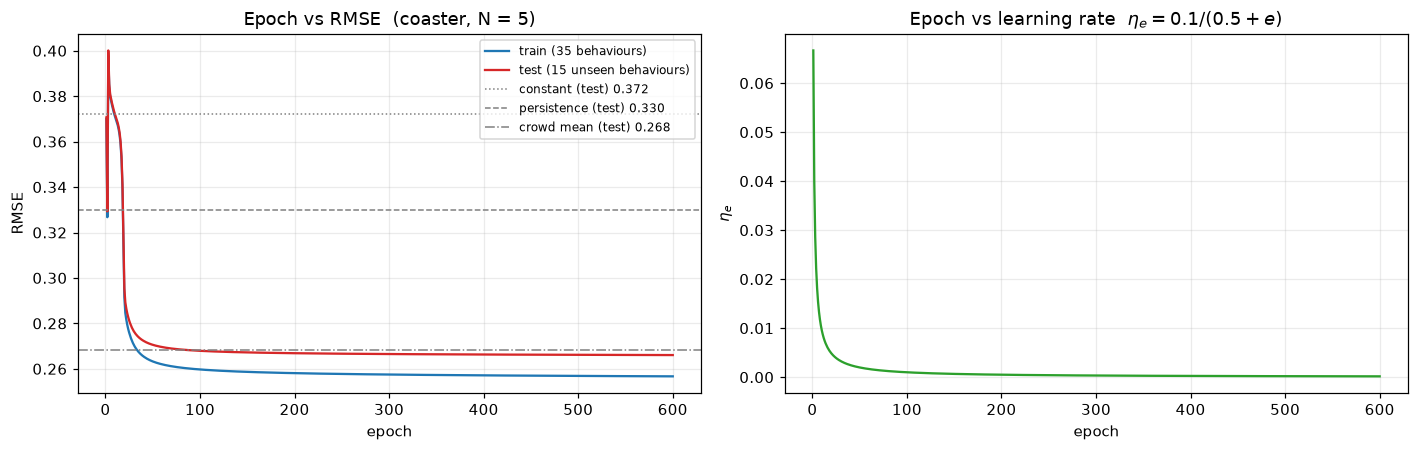

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

ax1.plot(LOG.epoch, LOG.train_rmse, label="train (35 behaviours)", color="#1f77b4")
ax1.plot(LOG.epoch, LOG.test_rmse,  label="test (15 unseen behaviours)", color="#d62728")
for (name, val), ls in zip(BASE_TE.items(), [":", "--", "-."]):
    ax1.axhline(val, color="grey", ls=ls, lw=1, label=f"{name} (test) {val:.3f}")
ax1.set_xlabel("epoch"); ax1.set_ylabel("RMSE")
ax1.set_title(f"Epoch vs RMSE  ({cfg.video}, N = {cfg.order})")
ax1.legend(fontsize=8)

ax2.plot(LOG.epoch, LOG.lr, color="#2ca02c")
ax2.set_xlabel("epoch"); ax2.set_ylabel(r"$\eta_e$")
ax2.set_title(rf"Epoch vs learning rate  $\eta_e = {cfg.lr_a}/({cfg.lr_b}+e)$")

plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "rmse_and_lr_vs_epoch.png"), dpi=130)
plt.show()

In [23]:
# The epoch table (every 50th epoch + the last)
show = LOG[(LOG.epoch == 1) | (LOG.epoch % 50 == 0)]
print(show[["epoch", "lr", "loss", "train_rmse", "test_rmse"]].round(5).to_string(index=False))

 epoch      lr     loss  train_rmse  test_rmse
     1 0.06667 27.37399     0.36996    0.37065
    50 0.00198 13.86003     0.26325    0.27057
   100 0.00100 13.49027     0.25971    0.26792
   150 0.00066 13.38004     0.25865    0.26722
   200 0.00050 13.32237     0.25809    0.26687
   250 0.00040 13.28556     0.25774    0.26665
   300 0.00033 13.25897     0.25748    0.26650
   350 0.00029 13.23848     0.25728    0.26638
   400 0.00025 13.22196     0.25712    0.26629
   450 0.00022 13.20829     0.25699    0.26622
   500 0.00020 13.19665     0.25687    0.26615
   550 0.00018 13.18656     0.25677    0.26610
   600 0.00017 13.17769     0.25669    0.26605


## 8. Did it converge, and is it better than the baselines?

Convergence is judged on the last 100 epochs: how much the train RMSE still
moved from epoch 500 to 600, compared with how much it moved over the whole run.

In [24]:
first, last100 = LOG.train_rmse.iloc[0], LOG.train_rmse.iloc[-100]
drop_total = first - FINAL_TR
drop_tail  = last100 - FINAL_TR
print(f"train RMSE  epoch 1: {first:.4f}  ->  end: {FINAL_TR:.4f}   (total drop {drop_total:.4f})")
print(f"drop over the last 100 epochs: {drop_tail:.5f} "
      f"({100*drop_tail/max(drop_total,1e-12):.1f}% of the total drop)")
print(f"sum of all learning rates: {LOG.lr.sum():.3f}\n")

summary = pd.DataFrame({
    "train RMSE": {**BASE_TR, "order-5 predictor": FINAL_TR},
    "test RMSE":  {**BASE_TE, "order-5 predictor": FINAL_TE},
}).sort_values("test RMSE")
print(summary.round(4))
summary.to_csv(os.path.join(OUT_DIR, "summary.csv"))

train RMSE  epoch 1: 0.3700  ->  end: 0.2567   (total drop 0.1133)
drop over the last 100 epochs: 0.00018 (0.2% of the total drop)
sum of all learning rates: 0.636

                   train RMSE  test RMSE
order-5 predictor      0.2567     0.2661
crowd mean             0.2529     0.2683
persistence            0.3132     0.3299
constant               0.3714     0.3720


### Test RMSE for each target sample

Is $F_6$ as hard to predict as $F_{12}$? Each row averages the 15 test behaviours.

In [25]:
pred_te = predict(X_te_t)
rows = []
for k in sorted(M_te.target_k.unique()):
    m = (M_te.target_k == k).values
    rows.append({"target": f"F{k}", "time (s)": k * cfg.sample_every_s,
                 "predictor": rmse(pred_te[m], Y_te[m]),
                 "persistence": rmse(X_te[m][..., -1], Y_te[m]),
                 "crowd mean": rmse(np.stack([crowd_by_k[k]] * m.sum()), Y_te[m])})
per_k = pd.DataFrame(rows)
print(per_k.round(4).to_string(index=False))

target  time (s)  predictor  persistence  crowd mean
    F6        30     0.2645       0.2757      0.2567
    F7        35     0.2457       0.3006      0.2552
    F8        40     0.2655       0.3459      0.2812
    F9        45     0.2579       0.3454      0.2666
   F10        50     0.3142       0.3651      0.3127
   F11        55     0.2275       0.3367      0.1976
   F12        60     0.2787       0.3312      0.2934


### One test behaviour: 5 inputs → prediction vs truth

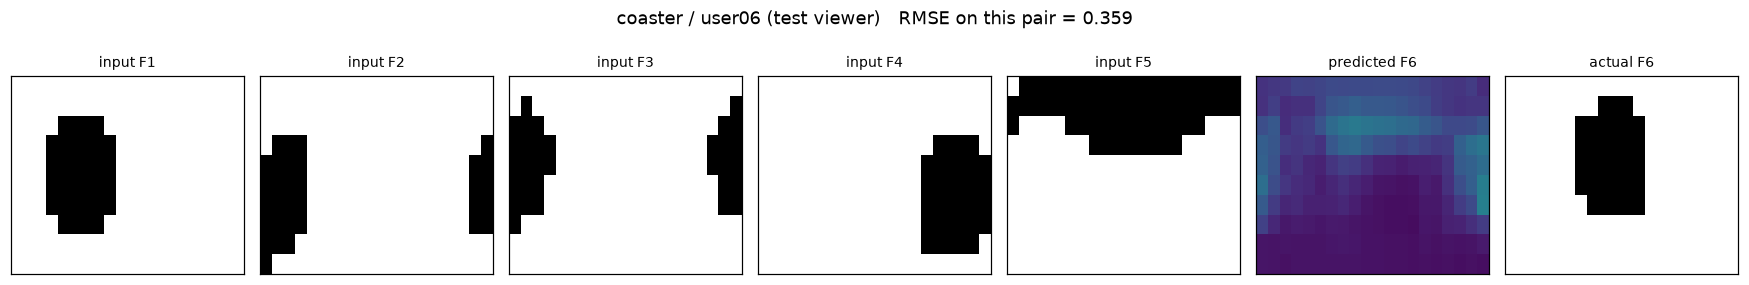

In [26]:
i = 0
u, k = M_te.iloc[i].user, M_te.iloc[i].target_k
fig, axes = plt.subplots(1, 7, figsize=(16, 2.6))
for j in range(cfg.order):
    axes[j].imshow(X_te[i][..., j], cmap="Greys", vmin=0, vmax=1, aspect="auto")
    axes[j].set_title(f"input F{k - cfg.order + j}", fontsize=9)
axes[5].imshow(pred_te[i], cmap="viridis", vmin=0, vmax=1, aspect="auto")
axes[5].set_title(f"predicted F{k}", fontsize=9)
axes[6].imshow(Y_te[i], cmap="Greys", vmin=0, vmax=1, aspect="auto")
axes[6].set_title(f"actual F{k}", fontsize=9)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"{cfg.video} / {u} (test viewer)   RMSE on this pair = "
             f"{rmse(pred_te[i], Y_te[i]):.3f}")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "example_prediction.png"), dpi=130)
plt.show()

## 9. Notes for presenting this

* **`a` and `b` still need confirming.** Everything above uses `a = 0.1`, `b = 0.5`.
  Changing them only needs the config cell and a re-run.
* **Why the loss is a sum over tiles.** The teacher's $\lVert\cdot\rVert_2^2$ is the squared
  L2 norm of the whole 10×20 error map, so it adds up 200 tile errors. RMSE is the
  per-tile version of the same quantity: $\text{RMSE} = \sqrt{L / 200}$ for a single pair.
* **One step per epoch.** The update rule is written per epoch, so each epoch is one
  full-batch gradient step over the 245 training pairs.
* **Single frames, not unions.** $F_k$ is one frame, as in "1 sample/frame per 5 s".
  What the viewer did during the 5 s between samples is not used.
* **Small data.** 245 training pairs from one video. The test set is 15 viewers, so
  small differences between models are within noise.